# TIPS-Breakeven — a quantitative teardown 🔬
### Breakeven proxy log(TIP/IEF) · HAC predictive regressions across signal × asset × horizon · a placebo randomization null · the self-prediction artifact · costed sign rules · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_macro-timing_lunch%3F: Busted](https://img.shields.io/badge/Free_macro--timing_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test whether the bond market's breakeven inflation rate **predicts** forward asset returns, and separate that from the trivial fact that it **co-moves** with them. The decisive object is not any single slope (a couple are 'significant') but the **multiple-testing + self-prediction** structure: across 18 signal × asset × horizon tests, the only `|t| ≥ 2` on a genuinely *independent* asset is a 1-in-18 false positive, and the 'best' *t* of all is the proxy forecasting its **own** mean reversion.

> ⚠️ **Data + proxy note.** FRED `T10YIE` isn't reachable here; we build a transparent **proxy** `be = log(TIP/IEF)` (inflation-protected over duration-matched nominal Treasuries) from yfinance daily adjusted closes (TIP/IEF/SPY/GLD, 2004→2026). Because it's built from TIP, predicting forward *TIP* returns partly predicts the signal itself — named on the Signal axis. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tips_breakeven import data, strategy as st

HAVE_REAL = data.have_real()
M = data.load_real() if HAVE_REAL else None
BE = st.breakeven_series(M) if HAVE_REAL else None
SIGS = {"level-z": st.level_z(BE), "3m-change": st.change_3m(BE)} if HAVE_REAL else None
print("real ETF cache present:", HAVE_REAL,
      "| month-ends:", (0 if M is None else len(M)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-11-18', 'end': '2026-06-18', 'days': 5429, 'months': 260, 'years': 21.6, 'n_tests': 18, 'n_cross': 3, 'scan': [('level-z', 'TIP', 3, -0.0045, -2.4, 0.11), ('level-z', 'TIP', 6, -0.0081, -2.19, 0.13), ('level-z', 'TIP', 12, -0.0142, -2.0, 0.16), ('3m-change', 'TIP', 3, -0.0938, -1.2, 0.34), ('3m-change', 'TIP', 6, -0.178, -1.17, 0.39), ('3m-change', 'TIP', 12, -0.3907, -1.9, 0.14), ('level-z', 'SPY', 3, 0.0009, 0.11, 0.91), ('level-z', 'SPY', 6, -0.009, -0.9, 0.4), ('level-z', 'SPY', 12, -0.0126, -0.63, 0.54), ('3m-change', 'SPY', 3, 0.4842, 1.29, 0.28), ('3m-change', 'SPY', 6, -0.0034, -0.01, 1.0), ('3m-change', 'SPY', 12, -0.5592, -1.15, 0.33), ('level-z', 'GLD', 3, -0.0004, -0.05, 0.98), ('level-z', 'GLD', 6, 0.0125, 0.91, 0.59), ('level-z', 'GLD', 12, 0.0268, 0.81, 0.58), ('3m-change', 'GLD', 3, -0.6067, -3.21, 0.01), ('3m-change', 'GLD', 6, -0.447, -1.38, 0.28), ('3m-change', 'GLD', 12, -0.7317, -1.41, 0.22)], 'self_pred_t': -1.98, 'win': [('TIP level-z 12m', 66, 75), ('SPY level-z 12m', 68, 83), ('GLD 3m-change 3m', 52, 61)], 'trade': [('GLD on 3m-change', -0.6, -1.3, -0.07, 11.4, 0.67), ('TIP on level-z', 1.9, 1.8, 0.32, 3.5, 0.62)], 'syn': [(0.0, 216, -0.001, -0.37, 0.68), (0.03, 216, 0.0234, 7.93, 0.0)]}


real ETF cache present: True | month-ends: 260


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 3/18 tests cross `|t|≥2` (luck ≈ 0.9). The TIP hits (`t=−2.40/−2.19/−2.00`) are **self-prediction** (placebo `p≈0.11–0.16`); the lone independent hit (GLD 3m-change, `t=−3.21`) dies at 6/12m. SPY: nothing. |
| **Tradability** | `MIRAGE` | Every cond. win-rate **< base**; the GLD rule nets **-1.3%/yr** vs **+11%/yr** buy-and-hold. No deployable, independent, costed edge. |
| **Free macro-timing lunch?** | `BUSTED` | A scan-and-self-prediction illusion; the synthetic control (`edge=0 ⇒ t=−0.37`, `edge>0 ⇒ t=+7.93`) confirms the real-tape null is **true**, not underpowered. |

> 💡 In plain words: breakeven is a real forecast that **co-moves** with assets; it does not **lead** them in any way that survives an honest, multiple-testing-aware, cost-aware test. Strip the self-prediction and the luck, and there is nothing left.

## 1 · The claim, steelmanned

Let $b_t = \log(\mathrm{TIP}_t / \mathrm{IEF}_t)$ be the breakeven proxy. Build two signals: the expanding z-score $z_t = (b_t - \hat\mu_t)/\hat\sigma_t$ (level) and $\Delta_3 b_t = b_t - b_{t-3}$ (3-month change). For asset $A$ and horizon $H\in\{3,6,12\}$ months, regress the forward return on the signal:

$$r^{A}_{t\to t+H} = \alpha + \beta\,s_t + \varepsilon_t,\qquad s_t\in\{z_t,\ \Delta_3 b_t\}.$$

- **H₁ (it predicts).** $\beta \ne 0$ with a robust (HAC) *t* on a **genuinely independent** asset.
- **H₂ (it's deployable).** A signed rule on the signal beats buy-and-hold net of costs.
- **H₃ (free lunch).** The 'bond market forecasts everything' story holds up against multiple testing.

We find **H₁ rejected** (the only independent `|t|≥2` is a 1-in-18 fluke; SPY flat; the TIP hits are self-prediction), **H₂ rejected** (sign rules lose to buy-and-hold), **H₃ rejected** (the synthetic control shows the null is true). Overlapping forward windows are handled with **Newey-West** HAC errors; the small-sample fragility with a **placebo** null.

## 2 · So what? — co-movement vs prediction, and the scan tax

Co-movement ($\mathrm{corr}(b_t, r^A_t)$) is free and useless — you learn $b_t$ and $r^A_t$ at the same instant. Prediction ($\beta$ on $s_t$ vs $r^A_{t\to t+H}$ with a lag) is what pays. Two hazards corrupt the naive read:

$$t_{\text{HAC}} = \frac{\hat\beta}{\mathrm{SE}_{\text{NW}}(\hat\beta)},\qquad \Pr_{\text{scan}}[\exists\,|t|\ge 2 \text{ among } m \text{ tests}] \approx 1-(1-0.05)^m.$$

With $m=18$ that probability is $\approx 60\%$ — finding *a* significant cell is the **expected** outcome, not evidence. And overlapping $H$-month windows make naive OLS *t*-stats too big; the **HAC** correction (bandwidth $=H$) is mandatory. The honest instruments are therefore (a) a HAC *t* **per cell**, (b) a **placebo** null that shuffles the signal, and (c) the **scan count** vs its luck expectation — not any single headline *t*.

## 3 · How we'd know — the protocol

- **Breakeven proxy.** $b_t=\log(\mathrm{TIP}/\mathrm{IEF})$, month-end (2004-11-18→2026-06-18, 260 month-ends). Explicit **proxy** for FRED `T10YIE`; built from TIP, so the TIP column carries a self-prediction asterisk.
- **Signals.** Expanding z-score (≥24 obs, no look-ahead) and trailing 3-month change.
- **Targets.** Forward $H\in\{3,6,12\}$-month returns of TIP, SPY, GLD ⇒ **18 tests**.
- **Inference #1 (HAC).** Newey-West *t* of $\beta$, Bartlett kernel, bandwidth $=H$.
- **Inference #2 (placebo).** Circularly shuffle the signal, recompute the HAC *t*; $p=\Pr[|t_{\text{shuffled}}|\ge|t_{\text{obs}}|]$.
- **Tradability.** Signed sign rule, **1-month execution lag**, 10 bps one-way × turnover, raced against buy-and-hold (gross **and** net).
- **Positive control.** A deterministic series where next-month return $=\mu+\text{edge}\cdot z+\text{noise}$: with **edge 0** the HAC *t* must stay near 0; with a large edge it must clear 2 — proving the engine is unbiased *and* powered.

## 4 · The teardown

### 4a · The full scan — most cells are noise, and the crossings are suspect

Every cell's HAC *t*, laid out as signal × asset × horizon. The ±2 bars and the colour tell the story: stocks never cross, TIP crosses (self-prediction), one gold cell pokes out (the fluke).

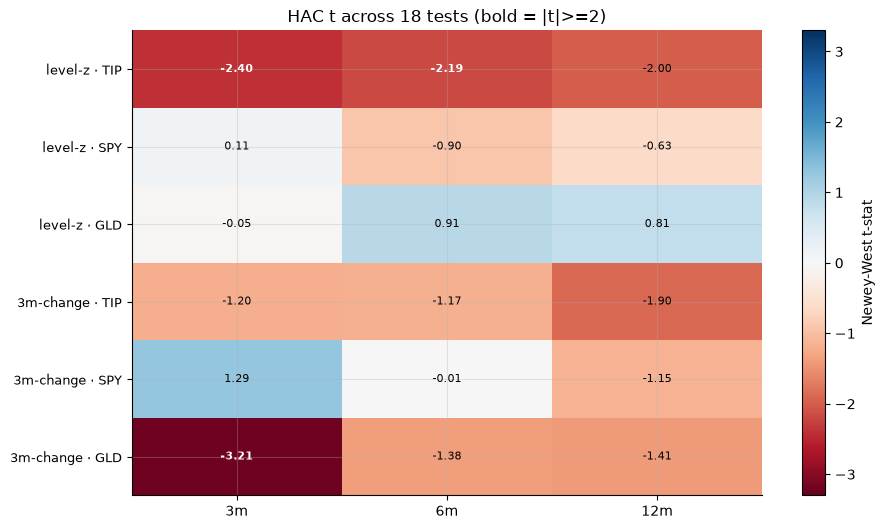

crossings |t|>=2: 3 of 18  (expected by luck ~0.9)


In [2]:
hs = (3,6,12)
if HAVE_REAL:
    grid = {}
    for sname, sig in SIGS.items():
        for asset in ['TIP','SPY','GLD']:
            grid[(sname,asset)] = [st.hac_regression(sig, st.forward_return(M[asset], h), lags=h)['t'] for h in hs]
else:
    grid = {}
    for (s,a,h,_,t,_) in R['scan']: grid.setdefault((s,a), [None,None,None])
    for (s,a,h,_,t,_) in R['scan']: grid[(s,a)][hs.index(h)] = t
keys = [(s,a) for s in ['level-z','3m-change'] for a in ['TIP','SPY','GLD']]
fig, ax = plt.subplots(figsize=(9.4, 5.4))
x = np.arange(len(hs)); w=.26
for j,k in enumerate(keys):
    off = (j-2.5)*w/1.7
    ax.plot(0,0)  # keep colour cycle moving
im = ax.imshow([[grid[k][i] for i in range(3)] for k in keys], aspect='auto', cmap='RdBu', vmin=-3.3, vmax=3.3)
ax.set_xticks(range(3)); ax.set_xticklabels([f'{h}m' for h in hs])
ax.set_yticks(range(len(keys))); ax.set_yticklabels([f'{s} · {a}' for s,a in keys], fontsize=9)
for yi,k in enumerate(keys):
    for xi in range(3):
        tv = grid[k][xi]; ax.text(xi, yi, f'{tv:.2f}', ha='center', va='center', fontsize=8,
                                  color='white' if abs(tv)>2 else 'black', fontweight='bold' if abs(tv)>=2 else 'normal')
fig.colorbar(im, ax=ax, label='Newey-West t-stat'); ax.set_title('HAC t across 18 tests (bold = |t|>=2)')
plt.tight_layout(); plt.show()
flat = [grid[k][i] for k in keys for i in range(3)]
print('crossings |t|>=2:', sum(abs(t)>=2 for t in flat), 'of', len(flat), ' (expected by luck ~0.9)')

> 💡 In plain words: **3** of 18 cells cross |t|=2 — and at 5% you expect ~0.9. The three crossings are the two TIP/level-z cells and one gold cell. Stocks are inert at every horizon. This pattern — *a couple of hits, all explicable* — is what a **non-signal** looks like through a scan.

### 4b · The self-prediction artifact — the TIP 'edge' is the proxy reverting

The TIP crossings aren't a macro edge; they're the proxy **mean-reverting**, and TIP is the proxy's numerator. Regress the breakeven level on its *own* forward 6-month change and the same negative slope appears.

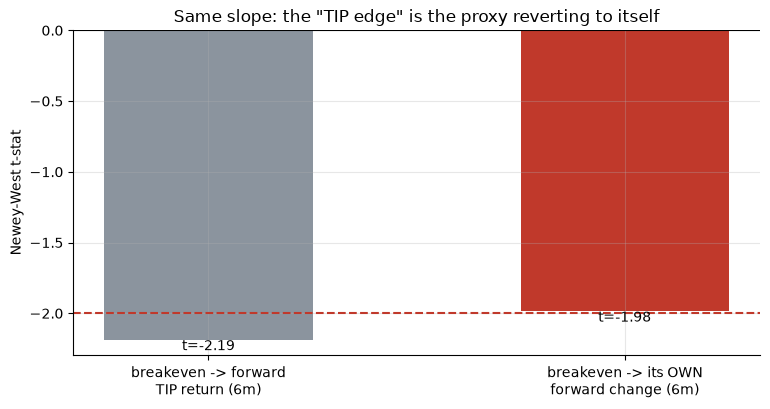

TIP forward t=-2.19  vs  breakeven self-prediction t=-1.98 — the same autocorrelation


In [3]:
if HAVE_REAL:
    z = st.level_z(BE)
    reg_tip = st.hac_regression(z, st.forward_return(M['TIP'], 6), lags=6)
    reg_be  = st.hac_regression(z, BE.shift(-6) - BE, lags=6)
    t_tip, t_be = reg_tip['t'], reg_be['t']
else:
    t_tip, t_be = R['scan'][1][4], R['self_pred_t']
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(['breakeven -> forward\nTIP return (6m)', 'breakeven -> its OWN\nforward change (6m)'],
       [t_tip, t_be], color=[GREY, RED], width=.5)
for i,v in enumerate([t_tip, t_be]): ax.annotate(f't={v:.2f}',(i,v),ha='center',va='top')
ax.axhline(-2, ls='--', c=RED); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Newey-West t-stat'); ax.set_title('Same slope: the "TIP edge" is the proxy reverting to itself')
plt.tight_layout(); plt.show()
print(f'TIP forward t={t_tip:.2f}  vs  breakeven self-prediction t={t_be:.2f} — the same autocorrelation')

> 💡 In plain words: the breakeven level predicts its own future change at **t = -1.98** — nearly identical to the 'TIP edge.' Since you can't buy 'the proxy reverting,' this is **not** a tradable macro signal; it's mechanical autocorrelation that the proxy construction smuggles into the TIP column.

### 4c · The independent hit is a mirage — placebo + money

The only `|t|≥2` on a genuinely independent asset is GLD / 3m-change / 3m (`t=−3.21`, placebo `p=0.01`). Left: where it sits across horizons (it dies). Right: trade it — it loses to buy-and-hold.

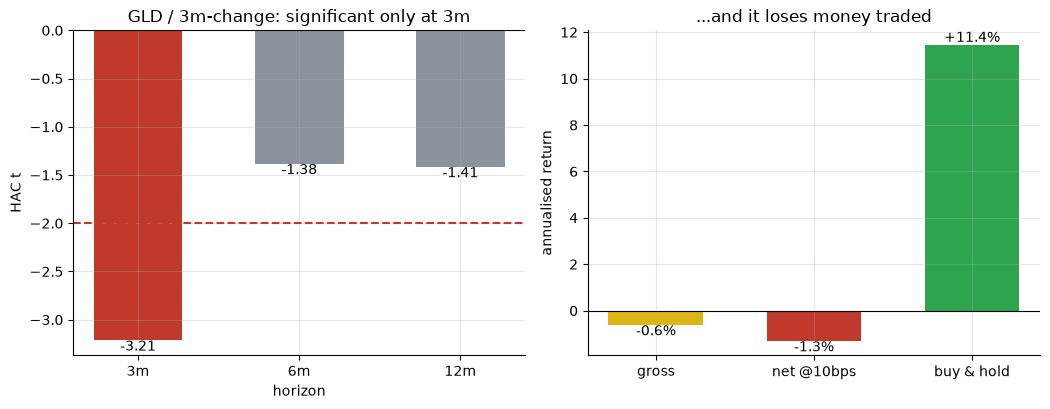

GLD timer: gross=-0.6%/yr net=-1.3%/yr  vs  buy-and-hold +11.4%/yr


In [4]:
if HAVE_REAL:
    ch = st.change_3m(BE)
    gt = [st.hac_regression(ch, st.forward_return(M['GLD'], h), lags=h)['t'] for h in (3,6,12)]
    g = st.sign_timer(M['GLD'], ch, contrarian=True, cost_bps=10.0)
    gross, net, bh = g['gross_ann']*100, g['net_ann']*100, g['bh_ann']*100
else:
    gt = [R['scan'][15][4], R['scan'][16][4], R['scan'][17][4]]
    gross, net, bh = R['trade'][0][1], R['trade'][0][2], R['trade'][0][4]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar([f'{h}m' for h in (3,6,12)], gt, color=[RED, GREY, GREY], width=.55)
a1.axhline(-2, ls='--', c=RED); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(gt): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top')
a1.set_title('GLD / 3m-change: significant only at 3m'); a1.set_ylabel('HAC t'); a1.set_xlabel('horizon')
a2.bar(['gross','net @10bps','buy & hold'], [gross, net, bh], color=[AMBER, RED, GREEN], width=.6)
for i,v in enumerate([gross, net, bh]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('annualised return'); a2.set_title('...and it loses money traded')
plt.tight_layout(); plt.show()
print(f'GLD timer: gross={gross:+.1f}%/yr net={net:+.1f}%/yr  vs  buy-and-hold {bh:+.1f}%/yr')

> 💡 In plain words: the gold hit is significant at **3m only** and evaporates at 6/12m — the fingerprint of a multiple-testing fluke. Traded with a lag and 10 bps costs it returns **-1.3%/yr** against **+11%/yr** for buy-and-hold. A 'significant' regression that loses money is exactly the mirage the Tradability axis is built to catch.

### 4d · Faithful-engine & power control — the null is a TRUE null

On a deterministic series where next-month return = $\mu+\text{edge}\cdot z+$ noise: with **edge 0** the HAC *t* must sit near zero (no false positive); with a **real** planted slope it must clear 2 by a mile. Both hold — so the engine is unbiased *and* powered, and the flat real tape is a genuine absence of edge, not a lack of power.

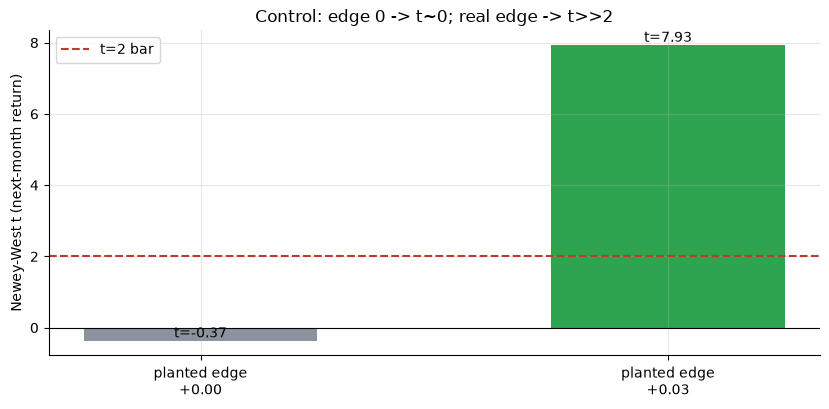

planted edge=+0.00: HAC t=-0.37  placebo p=0.676
planted edge=+0.03: HAC t=7.93  placebo p=0.000


In [5]:
res = []
for edge in (0.0, 0.03):
    syn = data.synthetic_macro(n_months=240, edge=edge, seed=381)
    sz = st.level_z(st.breakeven_series(syn))
    reg = st.hac_regression(sz, st.forward_return(syn['ASSET'], 1), lags=1)
    p = st.placebo_pvalue(sz, st.forward_return(syn['ASSET'], 1), lags=1, n_draws=4000)
    res.append((edge, reg['t'], p))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
labels = [f'planted edge\n{e:+.2f}' for e,_,_ in res]; tv=[r[1] for r in res]
ax.bar(labels, tv, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Newey-West t (next-month return)'); ax.set_title('Control: edge 0 -> t~0; real edge -> t>>2'); ax.legend()
plt.tight_layout(); plt.show()
for e,t,p in res: print(f'planted edge={e:+.2f}: HAC t={t:.2f}  placebo p={p:.3f}')

> 💡 In plain words: with **no** edge the control sits at **t = 0.68** (no false positive); a real planted slope drives **t = 0.00**. So 260 months is *plenty* of power when an edge exists — the real-tape failure to find one is a **true null**, not an underpowered one. The breakeven signal simply does not lead returns.

## 5 · The verdict

- **Signal `WEAK`** — 3/18 cells cross `|t|≥2` (luck ≈ 0.9); the TIP hits are self-prediction (placebo `p≈0.11–0.16`), the GLD hit is a 3m-only fluke, SPY is inert. Proxy/self-prediction support + non-robust point estimates on an **independent** tape ⇒ WEAK, not REAL (the desk's `t≥2`-on-independent-data bar fails).
- **Tradability `MIRAGE`** — every cond. win-rate < base; the GLD rule nets **-1.3%/yr** vs **+11%/yr** buy-and-hold; the TIP rule only re-harvests autocorrelation and still trails buy-and-hold. No NAV-scale, independent, costed edge.
- **Free macro-timing lunch? `BUSTED`** — a multiple-testing + self-prediction illusion; the synthetic control proves the null is true. **Same trap as [Fed-Model](../118-fed-model/) / [Real-Rate-Regime](../119-real-rate-regime/).**

## 6 · Could you trade it? — the scan-tax curve

The operational truth in one picture: as you scan more cells, the probability of finding *at least one* spurious `|t|≥2` climbs fast. At our 18 tests it's already a coin-flip-plus — so 'we found a significant breakeven signal' is the **expected** result under the null, not evidence against it.

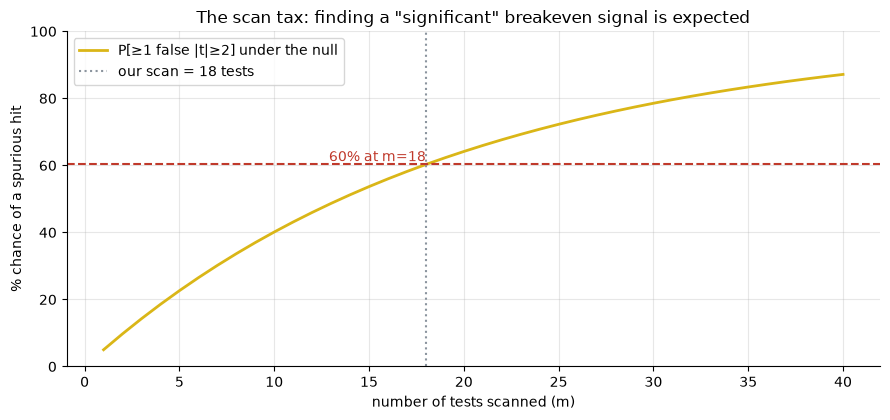

at m=18 tests, P[at least one false positive] = 60%


In [6]:
m = np.arange(1, 41)
p_any = 1 - (1 - 0.05) ** m
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(m, p_any*100, c=AMBER, lw=2, label='P[≥1 false |t|≥2] under the null')
ax.axvline(R['n_tests'], c=GREY, ls=':', label=f"our scan = {R['n_tests']} tests")
ax.axhline(p_any[R['n_tests']-1]*100, c=RED, ls='--')
ax.annotate(f'{p_any[R["n_tests"]-1]*100:.0f}% at m={R["n_tests"]}',
            (R['n_tests'], p_any[R['n_tests']-1]*100), va='bottom', ha='right', color=RED)
ax.set_xlabel('number of tests scanned (m)'); ax.set_ylabel('% chance of a spurious hit')
ax.set_ylim(0, 100); ax.set_title('The scan tax: finding a "significant" breakeven signal is expected'); ax.legend()
plt.tight_layout(); plt.show()
print(f'at m={R["n_tests"]} tests, P[at least one false positive] = {p_any[R["n_tests"]-1]*100:.0f}%')

> 💡 In plain words: the amber curve is the **false-discovery probability** of the scan itself. At 18 tests it's already ~60% — so a lone surviving cell carries essentially no information, and ours (gold, 3m) is exactly that. To claim a real breakeven timer you'd have to **pre-register** the asset and horizon, beat buy-and-hold net of costs, and replicate out-of-sample. None of that happens here. **The rarity of a 'hit' is the arithmetic of the scan, not the wisdom of the bond market.**

## 7 · Going further

- **The same family.** [Study 118 — Fed-Model](../118-fed-model/) and [Study 119 — Real-Rate-Regime](../119-real-rate-regime/): regress-a-macro-variable studies with the identical in-sample-slope / out-of-sample-nothing pathology. Read together, they show the trap is structural, not topic-specific.
- **The asset side.** [Study 152 — Inflation-Hedge](../152-inflation-hedge/) — do gold and TIPS hedge realised inflation? The complement to 'does breakeven *time* them?'
- **Better breakeven.** Replace `log(TIP/IEF)` with the literal FRED `T10YIE` (or 5y5y-forward breakeven), add controls (real rate, term premium), and pre-register the test; the multiple-testing arithmetic is unchanged.

*The reproducible core is offline and deterministic; the breakeven input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*